In [17]:
!pip install pandas matplotlib seaborn

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


In [19]:
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# 1. Análise do faturamento

In [32]:
faturamento_loja1 = loja['Preço'].sum()
faturamento_loja2 = loja2['Preço'].sum()
faturamento_loja3 = loja3['Preço'].sum()
faturamento_loja4 = loja4['Preço'].sum()

/tmp/ipython-input-850767372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loja', y='Faturamento', data=dados_faturamento, palette='viridis')


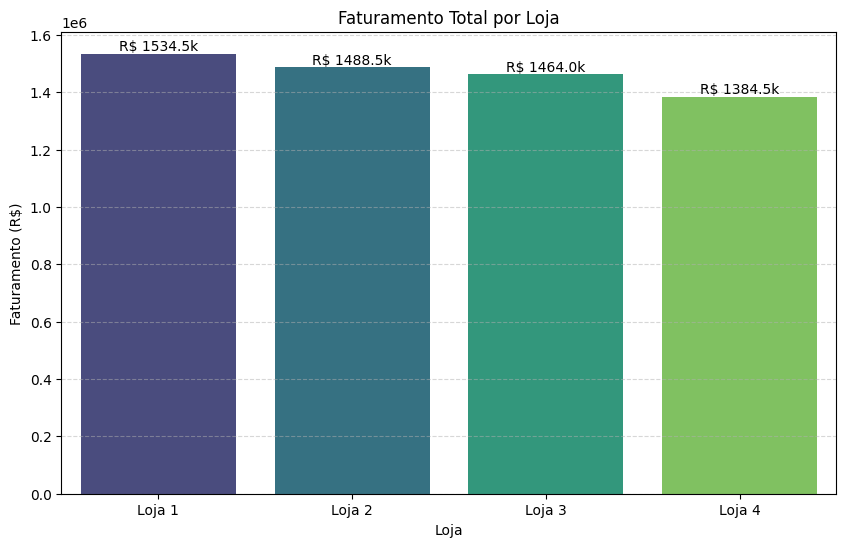

In [34]:
dados_faturamento = pd.DataFrame({
    'Loja': ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'],
    'Faturamento': [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]
})

dados_faturamento = dados_faturamento.sort_values(by='Faturamento', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Loja', y='Faturamento', data=dados_faturamento, palette='viridis')

plt.title('Faturamento Total por Loja')
plt.ylabel('Faturamento (R$)')

for i, (idx, row) in enumerate(dados_faturamento.iterrows()):
    plt.text(i, row['Faturamento'], f"R$ {row['Faturamento']/1000:.1f}k", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 2. Vendas por Categoria

In [38]:
df_combinado = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)
vendas_por_categoria_loja = df_combinado.groupby(['Loja', 'Categoria do Produto'])['Produto'].count().reset_index()
vendas_por_categoria_loja.rename(columns={'Produto': 'Quantidade Vendas'}, inplace=True)


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

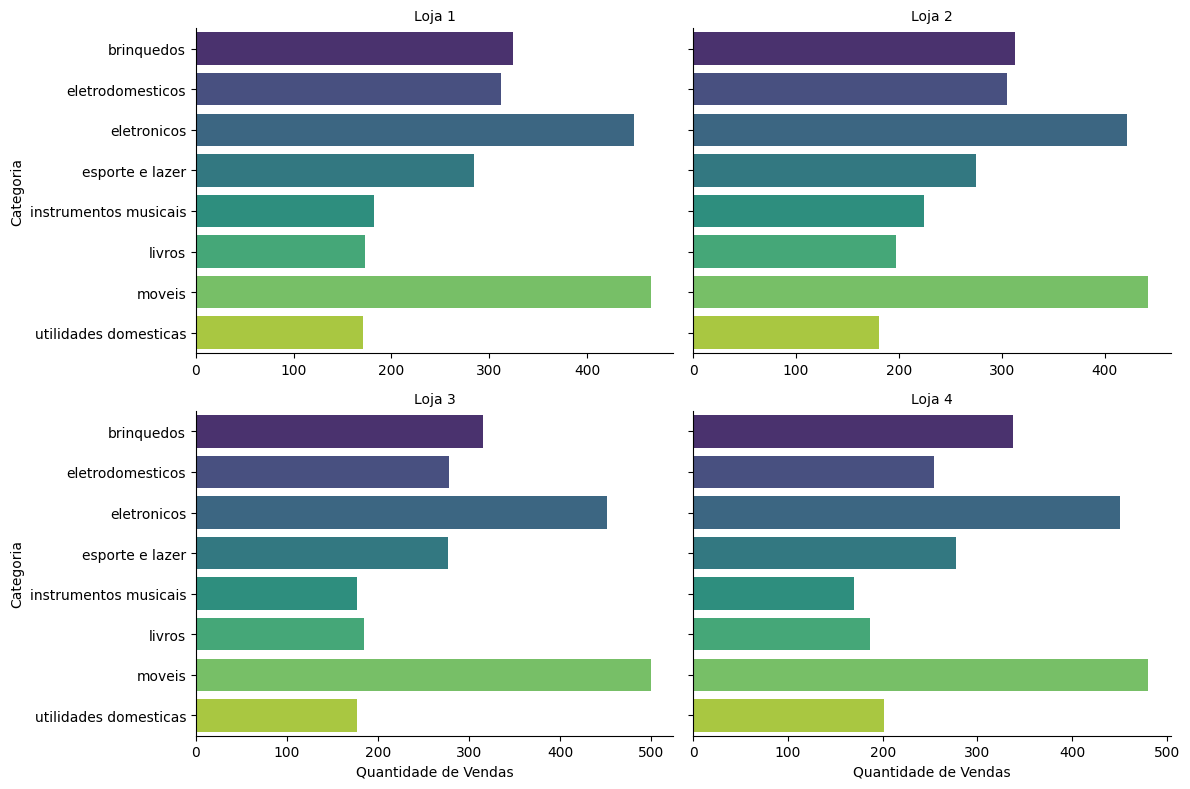

In [39]:
g = sns.FacetGrid(vendas_por_categoria_loja, col="Loja", col_wrap=2, height=4, aspect=1.5, sharex=False)
g.map_dataframe(sns.barplot, x="Quantidade Vendas", y="Categoria do Produto", palette="viridis")

g.set_titles("{col_name}") # Título de cada sub-gráfico
g.set_axis_labels("Quantidade de Vendas", "Categoria")

plt.tight_layout()
plt.show()

In [40]:
tabela = vendas_por_categoria_loja.pivot(index='Categoria do Produto', columns='Loja', values='Quantidade Vendas')
# Ordenar pela soma total para ver as categorias mais populares no geral primeiro
tabela['Total'] = tabela.sum(axis=1)
tabela = tabela.sort_values('Total', ascending=False).drop(columns='Total')
print(tabela)

Loja                   Loja 1  Loja 2  Loja 3  Loja 4
Categoria do Produto                                 
moveis                    465     442     499     480
eletronicos               448     422     451     451
brinquedos                324     313     315     338
eletrodomesticos          312     305     278     254
esporte e lazer           284     275     277     277
instrumentos musicais     182     224     177     170
livros                    173     197     185     187
utilidades domesticas     171     181     177     201


# 3. Média de Avaliação das Lojas


In [41]:
media_avaliacao = df_combinado.groupby('Loja')['Avaliação da compra'].mean().sort_values(ascending=False)
print(media_avaliacao)

Loja
Loja 3    4.048326
Loja 2    4.037304
Loja 4    3.995759
Loja 1    3.976685
Name: Avaliação da compra, dtype: float64


/tmp/ipython-input-4060202382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_avaliacao.index, y=media_avaliacao.values, palette='magma')


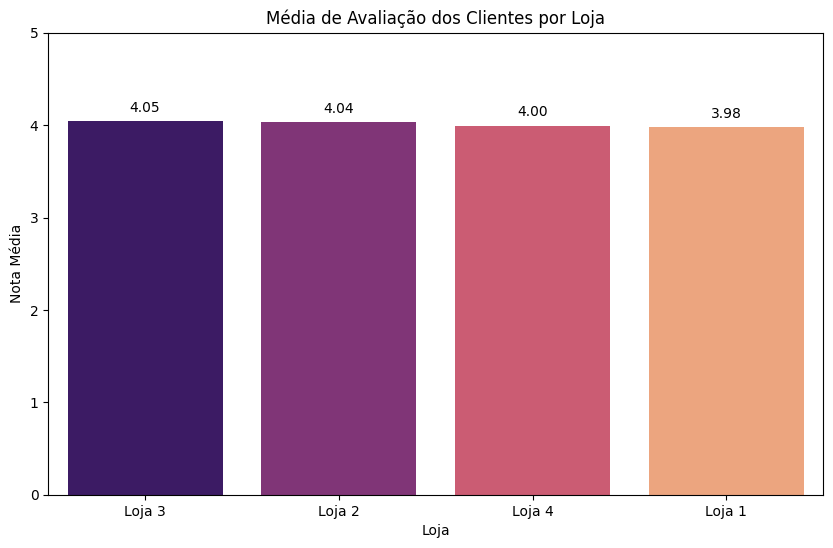

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(x=media_avaliacao.index, y=media_avaliacao.values, palette='magma')
plt.title('Média de Avaliação dos Clientes por Loja')
plt.ylim(0, 5)
plt.ylabel('Nota Média')

for i, valor in enumerate(media_avaliacao.values):
    plt.text(i, valor + 0.1, f"{valor:.2f}", ha='center')

plt.show()

# 4. Produtos Mais e Menos Vendidos

In [44]:
vendas_produto_loja = df_combinado.groupby(['Loja', 'Produto']).size().reset_index(name='Quantidade')

In [47]:
stores = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
df_top_list = []
df_bottom_list = []

for store in stores:
    dados_loja = vendas_produto_loja[vendas_produto_loja['Loja'] == store]

    df_top_list.append(dados_loja.nlargest(5, 'Quantidade'))

    df_bottom_list.append(dados_loja.nsmallest(5, 'Quantidade'))

df_top = pd.concat(df_top_list)
df_bottom = pd.concat(df_bottom_list)


print("--- Produtos Mais Vendidos ---")
print(df_top)
print("\n--- Produtos Menos Vendidos ---")
print(df_bottom)

--- Produtos Mais Vendidos ---
       Loja                   Produto  Quantidade
24   Loja 1             Guarda roupas          60
37   Loja 1               Micro-ondas          60
47   Loja 1             TV Led UHD 4K          60
43   Loja 1        Secadora de roupas          58
3    Loja 1          Blocos de montar          56
79   Loja 2  Iniciando em programação          65
88   Loja 2               Micro-ondas          62
52   Loja 2                   Bateria          61
91   Loja 2                  Pandeiro          58
100  Loja 2                    Violão          58
134  Loja 3             Kit banquetas          57
111  Loja 3                 Cama king          56
138  Loja 3            Mesa de jantar          56
119  Loja 3                    Cômoda          55
132  Loja 3           Jogo de panelas          55
161  Loja 4                  Cama box          62
173  Loja 4                  Faqueiro          59
162  Loja 4                 Cama king          56
171  Loja 4   Dashb

# 5. Frete Médio por Loja

In [51]:
frete_medio_loja = df_combinado.groupby('Loja')['Frete'].mean().sort_values(ascending=False)


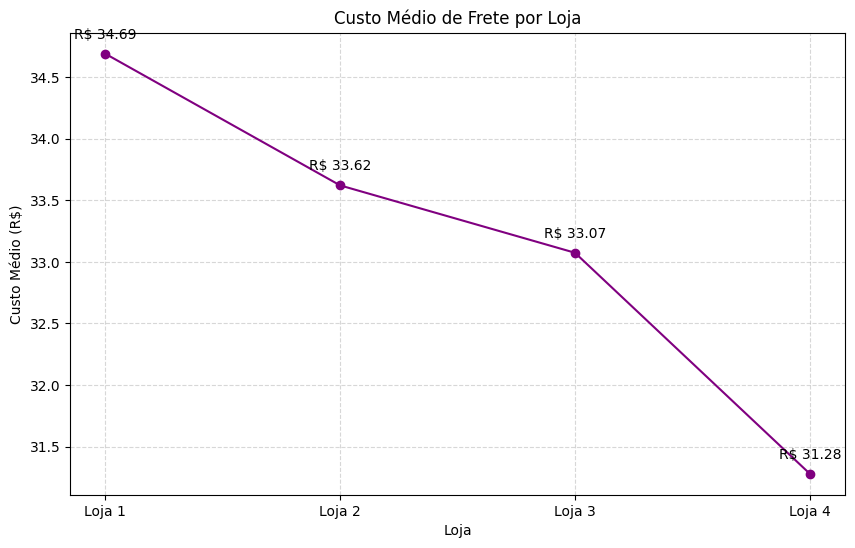

In [52]:
plt.figure(figsize=(10, 6))


plt.plot(frete_medio_loja.index, frete_medio_loja.values, marker='o', linestyle='-', color='purple')

plt.title('Custo Médio de Frete por Loja')
plt.xlabel('Loja')
plt.ylabel('Custo Médio (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
for x, y in zip(frete_medio_loja.index, frete_medio_loja.values):
    plt.text(x, y + 0.1, f"R$ {y:.2f}", ha='center', va='bottom')

plt.show()

# Relatório Estratégico

Análise de Desempenho das Lojas 1, 2, 3 e 4

Para: Senhor João

Data: 22 de Novembro de 2024

Assunto: Recomendação estratégica sobre venda de ativos (Filiais)

1. Introdução e Objetivo

Este relatório tem como objetivo apresentar uma análise baseada em dados do desempenho das quatro filiais da rede, cobrindo aspectos financeiros, operacionais e de satisfação do cliente. O intuito final é recomendar qual loja deve ser vendida (desinvestimento), identificando a unidade com menor potencial ou desempenho relativo frente às demais.

2. Desenvolvimento e Análise de Dados

A análise foi baseada nas bases de dados loja_1.csv, loja_2.csv, loja_3.csv e loja_4.csv. Abaixo estão os principais indicadores levantados.

2.1. Performance Financeira (Faturamento Total)

O faturamento é o indicador principal de porte e sucesso comercial da unidade.

Loja 1: R$ 1.534.509,12 (Maior Faturamento)

Loja 2: R$ 1.488.459,06

Loja 3: R$ 1.464.025,03

Loja 4: R$ 1.384.497,58 (Menor Faturamento)

Análise: A Loja 1 é a líder financeira, gerando cerca de R$ 150 mil a mais que a Loja 4. A Loja 4 apresenta o desempenho financeiro mais fraco do grupo.

2.2. Satisfação do Cliente (Média de Avaliações)

A média de avaliações (escala 1 a 5) reflete a fidelização e a qualidade do serviço na ponta.

Loja 3: 4.05 (Melhor Avaliada)

Loja 2: 4.04

Loja 4: 4.00

Loja 1: 3.98 (Pior Avaliada)

Análise: Embora as notas sejam próximas, a Loja 1, apesar de faturar muito, tem a pior avaliação, indicando possíveis problemas de atendimento ou produto. A Loja 3 é a favorita dos clientes.

2.3. Eficiência Operacional (Custo Médio de Frete)

O custo de frete impacta a decisão de compra do cliente e a margem líquida.

Loja 1: R$ 34,69 (Frete mais caro)

Loja 4: R$ 31,28 (Frete mais barato)

Análise: A Loja 4 é logisticamente mais eficiente ou atende regiões mais próximas, oferecendo o frete mais competitivo. A Loja 1 possui o frete mais oneroso, o que pode estar correlacionado com sua nota de avaliação mais baixa.

2.4. Mix de Produtos (Categorias e Itens)

Todas as lojas apresentam um perfil de vendas similar, focado em Móveis e Eletrônicos.

Produtos Destaque: Guarda-roupas, Micro-ondas e Livros de Programação (Loja 2).

Atenção: A Loja 1 depende fortemente de itens de ticket alto (Eletrodomésticos) para manter seu faturamento, enquanto a Loja 2 tem um volume surpreendente de venda de livros.

3. Conclusão e Recomendação

Considerando o cenário de reestruturação onde o Senhor João deseja vender uma das unidades, analisamos os trade-offs entre volume financeiro e qualidade operacional.

Recomendação: Vender a Loja 4

Justificativa:

Menor Volume Financeiro: A Loja 4 é a unidade com o menor faturamento total (R$ 1.38M). Em comparação com a líder (Loja 1), ela deixa de arrecadar uma quantia significativa que impacta o fluxo de caixa global da empresa.

Estagnação Relativa: Apesar de ter um frete competitivo e uma nota de avaliação razoável (4.00), ela não converte essas vantagens operacionais em volume de vendas superior. Ela é uma loja "correta", mas pequena.

Preservação das "Jóias":

Não venderíamos a Loja 1 pois, apesar da nota de avaliação ligeiramente menor, ela é a "vaca leiteira" do grupo (Cash Cow), trazendo a maior receita. Seus problemas de satisfação podem ser corrigidos com gestão, mas sua carteira de clientes é valiosa.

Não venderíamos a Loja 3 pois ela representa o equilíbrio ideal: bom faturamento e a melhor satisfação do cliente da rede.

Plano de Ação Sugerido:

Proceder com a avaliação de mercado (valuation) da Loja 4.

Para as lojas remanescentes (1, 2 e 3), implementar um plano de ação focado na Loja 1 para reduzir o custo de frete e melhorar a avaliação dos clientes, blindando assim a maior fonte de receita do grupo.

# Extras

# VISUALIZAÇÃO 1: Dispersão Geográfica por Loja

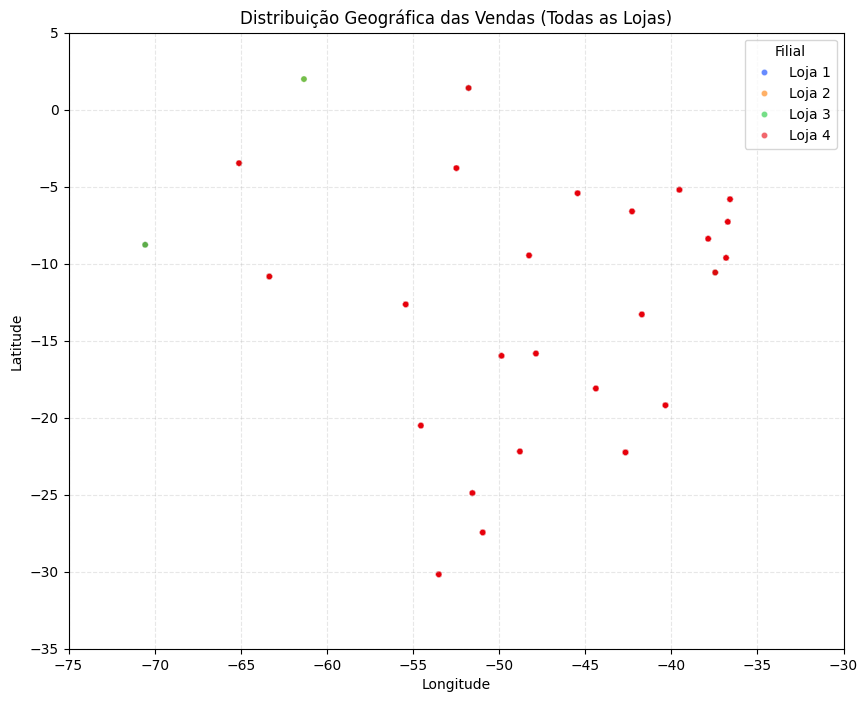

In [57]:
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df_combinado, x='lon', y='lat', hue='Loja', palette='bright', alpha=0.6, s=20)

plt.title('Distribuição Geográfica das Vendas (Todas as Lojas)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Filial')
plt.grid(True, linestyle='--', alpha=0.3)

plt.xlim(-75, -30) # Long
plt.ylim(-35, 5)   # Lat

plt.show()



# VISUALIZAÇÃO 2: Mapa de Calor (Densidade)


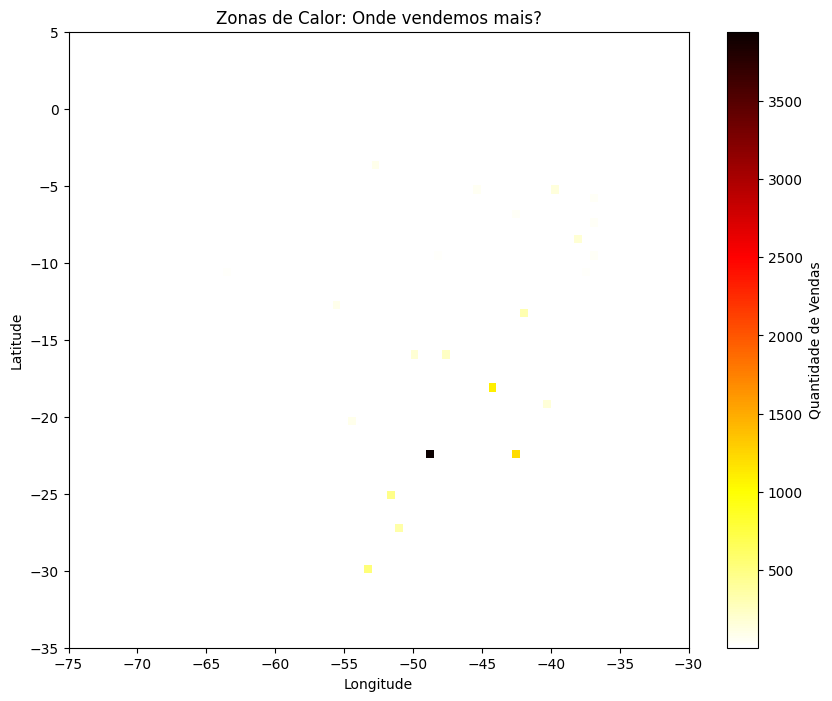

In [56]:
plt.figure(figsize=(10, 8))

plt.hist2d(df_combinado['lon'], df_combinado['lat'], bins=60, cmap='hot_r', cmin=1)

plt.colorbar(label='Quantidade de Vendas')
plt.title('Zonas de Calor: Onde vendemos mais?')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-75, -30)
plt.ylim(-35, 5)

plt.show()